Extracting raw samples using feature_map.yaml...


/tmp/ipykernel_13240/3748953428.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='farm', y='wind_speed', data=df_all_raw, palette='viridis')


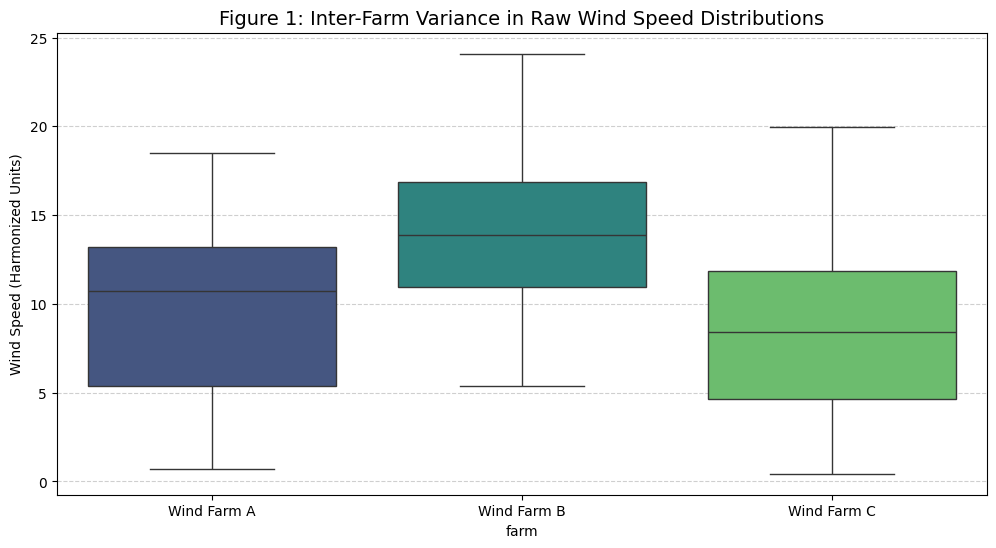

Loading Master Dataset: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/processed/master_dataset.parquet


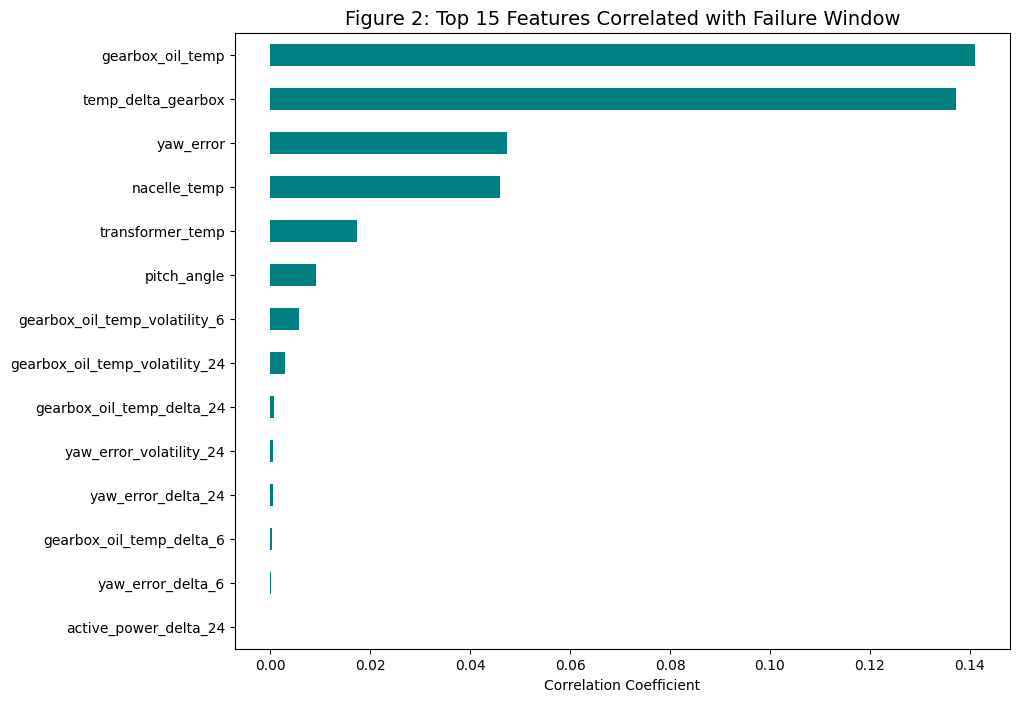

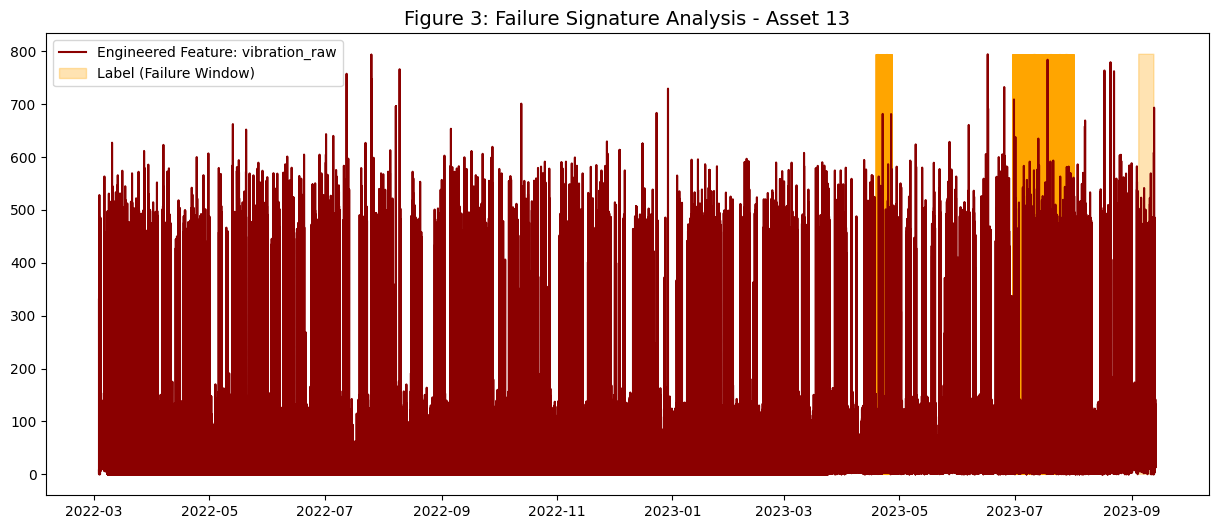

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
from pathlib import Path

# --- PATH SETUP ---
project_root = Path(os.getcwd()).parent
RAW_DATA_ROOT = project_root / "data" / "raw" / "zenodo_windfarm_data"
PROCESSED_DATA_DIR = project_root / "data" / "processed"
CONFIG_PATH = project_root / "config" / "feature_map.yaml"
MASTER_FILE = PROCESSED_DATA_DIR / "master_dataset.parquet"

# Load the feature map to handle heterogeneous naming
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

# --- PART 1: RAW DATA CHARACTERIZATION (Addressing the Error) ---
farms = {'A': 'Wind Farm A', 'B': 'Wind Farm B', 'C': 'Wind Farm C'}
raw_samples = []

print("Extracting raw samples using feature_map.yaml...")

for farm_id, farm_name in farms.items():
    farm_dir = RAW_DATA_ROOT / farm_name / "datasets"
    
    if farm_dir.exists():
        # Get the wind speed sensor name for this specific farm from config
        wind_col = config['farms'][farm_id]['sensors']['wind_speed']
        
        # Grab first available CSV
        try:
            sample_file = next(farm_dir.glob("*.csv"))
            df_raw = pd.read_csv(sample_file, sep=';', nrows=1000)
            
            # Harmonize just this one column for the plot
            temp_df = pd.DataFrame({
                'farm': farm_name,
                'wind_speed': pd.to_numeric(df_raw[wind_col], errors='coerce')
            })
            raw_samples.append(temp_df)
        except StopIteration:
            print(f"No files found in {farm_dir}")

df_all_raw = pd.concat(raw_samples).dropna()

# Visual 1: Inter-Farm Variation
plt.figure(figsize=(12, 6))
sns.boxplot(x='farm', y='wind_speed', data=df_all_raw, palette='viridis')
plt.title("Figure 1: Inter-Farm Variance in Raw Wind Speed Distributions", fontsize=14)
plt.ylabel("Wind Speed (Harmonized Units)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --- PART 2: PROCESSED DATA ANALYSIS ---
if MASTER_FILE.exists():
    print(f"Loading Master Dataset: {MASTER_FILE}")
    df_master = pd.read_parquet(MASTER_FILE)

    # 2.1 Feature Correlation (Evidence for Feature Selection)
    # Filter for numeric only and drop non-feature metadata
    cols_to_drop = ['time_stamp', 'asset_id', 'farm_id', 'target']
    numeric_df = df_master.select_dtypes(include=[np.number])
    correlations = numeric_df.corr()['target'].sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    correlations.drop('target', errors='ignore').plot(kind='barh', color='teal')
    plt.title("Figure 2: Top 15 Features Correlated with Failure Window", fontsize=14)
    plt.xlabel("Correlation Coefficient")
    plt.gca().invert_yaxis()
    plt.show()

    # 2.2 Intra-Turbine Failure Signature (e.g., Turbine 13)
    # Demonstrating the 24-48h lead-in logic from your preprocessing.py
    target_asset = "13" 
    turbine_df = df_master[df_master['asset_id'] == target_asset].sort_values('time_stamp')
    
    if not turbine_df.empty and (turbine_df['target'] == 1).any():
        plt.figure(figsize=(15, 6))
        # Use one of the high-correlation features found in Step 2.1
        feat = 'vibration_std_6h' if 'vibration_std_6h' in turbine_df.columns else 'vibration_raw'
        
        plt.plot(turbine_df['time_stamp'], turbine_df[feat], label=f'Engineered Feature: {feat}', color='darkred')
        plt.fill_between(turbine_df['time_stamp'], 0, turbine_df[feat].max(), 
                         where=turbine_df['target']==1, color='orange', alpha=0.3, label='Label (Failure Window)')
        
        plt.title(f"Figure 3: Failure Signature Analysis - Asset {target_asset}", fontsize=14)
        plt.legend()
        plt.show()
else:
    print("Master dataset not found. Ensure preprocessing.py has been executed.")